In [1]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)

import random
from itertools import combinations
import matplotlib as mpl
import matplotlib.cm as cm

import glob
import math
%matplotlib inline
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

from matplotlib.legend_handler import HandlerPatch
from matplotlib.backends.backend_pdf import PdfPages
import textwrap

import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

import pickle

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/home2/s223695/.local/lib/python3.12/site-packages', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]


numpy 1.26.4
pandas 2.2.1
scipy 1.15.3
matplotlib 3.8.3


### Load pySpade data

In [2]:
global_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/Manhattan_plots/filtered_df.csv')

In [3]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [4]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

In [5]:
global_df["Pert_name"] = global_df["region"].apply(lambda x: annot_dict[x])
print(global_df.columns)

global_df.head()

Index(['Unnamed: 0', 'idx', 'gene_names', 'chromosome', 'pos', 'strand',
       'color_idx', 'chr_idx', 'region', 'num_cell', 'bin',
       'log(pval)-hypergeom', 'fc', 'Significance_score',
       'fc_by_rand_dist_cpm', 'pval-empirical', 'cpm_perturb', 'cpm_bg',
       'Pert_name'],
      dtype='object')


,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684,NCOA1
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529,NCOA1
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946,NCOA1
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569,NCOA1
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102,NCOA1


### Load Gene Program regulation table

In [6]:
Pert_gp_path = '/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/compare_score_pert_all_k_all_targets_clear_gRNA_12_3_24.pkl'

with open(Pert_gp_path, 'rb') as file:
    compare_score_pert_all_ks = pickle.load(file)

In [7]:
gp_go_path = '/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/TF_full_GO_all_enriched_results.pkl'
with open(gp_go_path, 'rb') as file:
    enrichment_results = pickle.load(file)

In [8]:
top300_gene_path = "/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_full_cNMF_figure_2_plots/top_300_genes_K_250_per_program_TF_full.csv"
top300_gene_df = pd.read_csv(top300_gene_path)

In [9]:
!cp {top300_gene_path} ./output_data/top_300_genes_K_250_per_program_TF_full.csv

cp: cannot create regular file './output_data/top_300_genes_K_250_per_program_TF_full.csv': No such file or directory


In [10]:
top300_gene_df.head()

,1,2,3,4,5,6,7,8,9,10,...,241,242,243,244,245,246,247,248,249,250
0,FBN2,CACNA1D,NCCRP1,MT-CO3,SFRP1,GRIK1,ZNF385D,COL1A2,LMO2,H3F3B,...,AL031767.1,PHGR1,LY86,AC018730.1,AC113615.1,TRIM43B,SPDYC,AL035412.1,LINC00583,DDC
1,LAMA2,RSPO3,ZNF385B,MT-CO2,RAB3C,CKB,PRR16,ITGA8,DPP10,GADD45G,...,AL355337.1,AC103702.2,AC051619.8,C2CD4A,HID1-AS1,TRIM49,LINC02715,AC093824.2,KRT86,CTSE
2,MYL3,LBH,TBX18,MT-ATP8,PDE3A,MFGE8,FABP5,COL1A1,CADM1,PHLDA1,...,LINC02061,MATN4,AC009396.3,AC072061.1,RTBDN,MBD3L2,C5orf58,AC120498.4,PTPN7,AC006441.4
3,KCNQ5,EPHA7,TMEM98,MT-CO1,UNC5C,FST,DLGAP1,COL3A1,C7,JUN,...,FAM107A,AC026310.2,PTGDS,AC016888.1,AL596442.4,LEUTX,AL133551.1,AC016229.2,AL606923.2,GJB1
4,LAMA4,SLIT2,KCNMA1,MT-ND4L,AC022784.1,BMP4,PTCHD1-AS,GPC3,AC092691.1,CDKN1C,...,RASSF6,AC069214.1,HOXA2,LINC02071,DNER,TAF11L12,MCMDC2,AC099521.3,HMSD,DLL4


In [11]:
gp_regulation_df = compare_score_pert_all_ks["usage_norm_k_250"]
print(gp_regulation_df.columns)

gp_go_df = enrichment_results[250]
print(gp_go_df.columns)

Index(['Gene', 'Score Column', 'Statistic', 'p-value', 'Log2 Fold Change',
       'Corrected p-value (BH)'],
      dtype='object')
Index(['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value',
       'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score',
       'Genes', 'Source'],
      dtype='object')


In [12]:
gp_go_df[gp_go_df["Source"]==3].head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Source
4443,GO_Molecular_Function_2023,Cadherin Binding (GO:0045296),24/319,1.041807e-10,3.437964e-08,0,0,5.719971,131.472916,RANBP1;HSPA8;HSP90AB1;EEF2;PRDX6;BZW1;VASN;SEP...,3
4444,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),22/387,1.046641e-07,1.229822e-05,0,0,4.192076,67.377190,PDIA3;HSPA8;NPM1;TPM4;DYNLL1;ACTB;EGFR;ACTG1;C...,3
4445,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),22/395,1.492519e-07,1.229822e-05,0,0,4.100469,64.449650,PDIA3;HSPA8;NPM1;TPM4;DYNLL1;ACTB;EGFR;ACTG1;C...,3
4446,GO_Cellular_Component_2023,U4 snRNP (GO:0005687),5/10,1.740315e-07,1.229822e-05,0,0,66.762712,1039.096837,SNRPD2;SNRPD1;SNRPE;SNRPF;SNRPB,3
4447,GO_Molecular_Function_2023,RNA Binding (GO:0003723),48/1411,7.812229e-08,1.289018e-05,0,0,2.562555,41.936181,EIF4A1;HSP90AB1;TXN;HMGB1;BZW1;RRP9;RBM3;RIMS1...,3
4448,GO_Cellular_Component_2023,Collagen-Containing Extracellular Matrix (GO:0...,20/373,1.007865e-06,5.341682e-05,0,0,3.914812,54.054456,SBSPON;COL26A1;SPARC;RARRES2;MMP2;APLP1;SERPIN...,3
4449,GO_Cellular_Component_2023,U12-type Spliceosomal Complex (GO:0005689),6/28,3.091253e-06,1.310691e-04,0,0,18.254174,231.589506,LSM7;SNRPD2;SNRPD1;SNRPE;SNRPF;SNRPB,3
4450,GO_Cellular_Component_2023,U1 snRNP (GO:0005685),5/18,5.361192e-06,1.894288e-04,0,0,25.667536,311.509536,SNRPD2;SNRPD1;SNRPE;SNRPF;SNRPB,3
4451,GO_Cellular_Component_2023,Endoplasmic Reticulum Lumen (GO:0005788),16/284,6.652763e-06,1.904513e-04,0,0,4.084927,48.694289,PDIA3;COL26A1;IGFBP5;GOLM1;LAMC1;FSTL1;PDIA6;V...,3
4452,GO_Cellular_Component_2023,U5 snRNP (GO:0005682),5/19,7.186843e-06,1.904513e-04,0,0,23.832930,282.259551,SNRPD2;SNRPD1;SNRPE;SNRPF;SNRPB,3


### GP FDR detection analysis

In [13]:
gp_regulation_df.head()

,Gene,Score Column,Statistic,p-value,Log2 Fold Change,Corrected p-value (BH)
0,non-targeting (self),Usage_1,879230178.0,1.000000,NaN,1.000000
1,ADNP2-P1P2,Usage_1,11343150.5,0.221842,-0.060234,0.788741
2,AEBP1-P1P2,Usage_1,6742183.0,0.096836,0.136552,0.655981
3,AFF1-P1P2,Usage_1,24259033.5,0.999584,0.006465,1.000000
4,AFF2-P1P2,Usage_1,17320479.5,0.720667,0.026586,0.961013


In [14]:
all_pert_list_gp = gp_regulation_df["Gene"].unique()
OR_pert_list_gp = [gene_name for gene_name in all_pert_list_gp if gene_name.startswith("OR")]

In [15]:
FDR_cutoff_list = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]

for FDR_cutoff_gp in FDR_cutoff_list:
    gp_regulation_df_sig = gp_regulation_df[gp_regulation_df["Corrected p-value (BH)"]<FDR_cutoff_gp]
    gp_regulation_df_or = gp_regulation_df_sig[gp_regulation_df_sig["Gene"].apply(lambda x: x in OR_pert_list_gp)]
    
    sig_gp_reg_all_num = gp_regulation_df_sig.shape[0]
    sig_gp_reg_of_num = gp_regulation_df_or.shape[0]
    percent_or_reg = sig_gp_reg_of_num/sig_gp_reg_all_num*100
    sig_gp_unq = len(gp_regulation_df_sig["Score Column"].unique())
    
    
    print(f"Thresfold: {FDR_cutoff_gp}")
    print(f"\t Num of GP reg: {sig_gp_reg_all_num}")
    print(f"\t Num of GP reg with OR gene perturb: {sig_gp_reg_of_num}")
    print(f"\t Percent of OR pert regulationm: {percent_or_reg:.2f}")
    print(f"\t Num of GP regulated: {sig_gp_unq}")
    

Thresfold: 0.1
	 Num of GP reg: 6682
	 Num of GP reg with OR gene perturb: 75
	 Percent of OR pert regulationm: 1.12
	 Num of GP regulated: 250
Thresfold: 0.05
	 Num of GP reg: 4627
	 Num of GP reg with OR gene perturb: 37
	 Percent of OR pert regulationm: 0.80
	 Num of GP regulated: 250


Thresfold: 0.01
	 Num of GP reg: 2743
	 Num of GP reg with OR gene perturb: 6
	 Percent of OR pert regulationm: 0.22
	 Num of GP regulated: 247
Thresfold: 0.005
	 Num of GP reg: 2302
	 Num of GP reg with OR gene perturb: 6
	 Percent of OR pert regulationm: 0.26
	 Num of GP regulated: 243
Thresfold: 0.001
	 Num of GP reg: 1681
	 Num of GP reg with OR gene perturb: 1
	 Percent of OR pert regulationm: 0.06
	 Num of GP regulated: 232
Thresfold: 0.0005
	 Num of GP reg: 1527
	 Num of GP reg with OR gene perturb: 0
	 Percent of OR pert regulationm: 0.00
	 Num of GP regulated: 227
Thresfold: 0.0001
	 Num of GP reg: 1207
	 Num of GP reg with OR gene perturb: 0
	 Percent of OR pert regulationm: 0.00
	 Num of GP regulated: 216


In [16]:
FDR_cutoff_gp = 0.001
gp_regulation_df_sig = gp_regulation_df[gp_regulation_df["Corrected p-value (BH)"]<FDR_cutoff_gp].copy()

In [17]:
FDR_cutoff_go = 0.05
gp_go_df_sig = gp_go_df[gp_go_df["Adjusted P-value"]<FDR_cutoff_go].copy()

In [18]:
gp_regulation_df_sig_target = \
    gp_regulation_df_sig[gp_regulation_df_sig["Score Column"]=="Usage_1"].sort_values("Corrected p-value (BH)")

gp_regulation_df_sig_target_down = \
    gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']<0]
gp_regulation_df_sig_target_up = \
    gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']>0]

target_down_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_down["Gene"].values]

In [19]:
global_df.head()

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684,NCOA1
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529,NCOA1
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946,NCOA1
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569,NCOA1
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102,NCOA1


In [20]:
DEG_tf_regulation = global_df[(global_df["Pert_name"].apply(lambda x: x in target_down_tf_name)) & \
                              (global_df["gene_names"].apply(lambda x: x in target_down_tf_name))
                             ]

In [21]:
gp_name_list = gp_regulation_df["Score Column"].unique()

In [22]:
gp_regulation_df_sig[gp_regulation_df_sig["Gene"]=="MAP3K7-P2"].sort_values("Corrected p-value (BH)")

,Gene,Score Column,Statistic,p-value,Log2 Fold Change,Corrected p-value (BH)


In [23]:
gp_regulation_df_sig[gp_regulation_df_sig["Gene"]=="HOXB4-P1P2"]

,Gene,Score Column,Statistic,p-value,Log2 Fold Change,Corrected p-value (BH)
493,HOXB4-P1P2,Usage_1,7414673.0,2.323867e-29,0.647656,9.966911e-26
4679,HOXB4-P1P2,Usage_3,12561281.5,1.179461e-15,-1.312012,2.003744e-12
8865,HOXB4-P1P2,Usage_5,11792697.5,2.543946e-07,-0.707302,1.090227e-04
10958,HOXB4-P1P2,Usage_6,12618769.0,2.048544e-16,-1.109412,3.747904e-13
15144,HOXB4-P1P2,Usage_8,11830917.5,8.092912e-08,-0.779767,3.968713e-05
25609,HOXB4-P1P2,Usage_13,8812236.0,2.440848e-10,0.505116,2.043478e-07
27702,HOXB4-P1P2,Usage_14,9022911.5,2.240522e-07,0.379186,9.753354e-05
33981,HOXB4-P1P2,Usage_17,11654169.0,8.458556e-08,-2.076275,4.128675e-05
52818,HOXB4-P1P2,Usage_26,11695829.0,3.059777e-08,-0.457207,1.674716e-05
73748,HOXB4-P1P2,Usage_36,11654218.0,2.879430e-07,-1.091115,1.217013e-04


### GP regulating graph analysis

In [24]:
def generate_graph(TF_regulation_df, tf_name_list):
    # 2) Create a directed graph
    G = nx.DiGraph()

    # Add TF nodes to the graph
    G.add_nodes_from(tf_name_list)
    
    #Get expression level of the TFs
    tf_exp_series = \
        global_df[global_df["gene_names"].apply(lambda x: x in tf_name_list)].groupby("gene_names")["cpm_bg"].mean()
    
    # 3) Add edges
    # Edge direction: regulating_tf -> tf_name
    for row in TF_regulation_df.itertuples():
        # Remove self-loops
        if row.gene_names == row.Pert_name:
            continue

        # Add directed edges with attributes
        # We store log2FC for weight/width and -log10(p-value) for opacity
        log_fc = np.log2(row.fc)
        
        # Calculate negative log p-value (add small epsilon to avoid log(0))
        # Using pval_empirical based on your data structure
        nlog_p = -row.Significance_score
        
        G.add_edge(row.Pert_name, row.gene_names, weight=log_fc, significance=nlog_p)
    return G, tf_exp_series

In [25]:
graph_gp_dict = {}
tf_exp_sr_dict = {}

#Additional dict for total graph
graph_gp_total_dict = {}
tf_exp_sr_total_dict = {}

net_info_df = pd.DataFrame(columns=["Num_nodes","Num_edges","Density",
                                    "Max_indegree_node","Max_indegree_centrality","all_centrality"])

print("Generating graphs...")
for target_gene in tqdm(gp_name_list):
    gp_id = target_gene.split("_")[1]

    # Filter data (Same logic as your original code)
    gp_regulation_df_sig_target = \
        gp_regulation_df_sig[gp_regulation_df_sig["Score Column"]==target_gene].sort_values("Corrected p-value (BH)")

    gp_regulation_df_sig_target_down = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']<0]
    gp_regulation_df_sig_target_up = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']>0]

    target_down_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_down["Gene"].values]
    target_up_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_up["Gene"].values]
    taget_total_tf_name = np.unique(np.concatenate([target_down_tf_name, target_up_tf_name]))
    
    DEG_tf_regulation_down  = global_df[(global_df["Pert_name"].apply(lambda x: x in target_down_tf_name)) & \
                                        (global_df["gene_names"].apply(lambda x: x in target_down_tf_name))]
    DEG_tf_regulation_up    = global_df[(global_df["Pert_name"].apply(lambda x: x in target_up_tf_name)) & \
                                        (global_df["gene_names"].apply(lambda x: x in target_up_tf_name))]
    DEG_tf_regulation_total = global_df[(global_df["Pert_name"].apply(lambda x: x in taget_total_tf_name)) & \
                                        (global_df["gene_names"].apply(lambda x: x in taget_total_tf_name))]
    
    # Use the MODIFIED function
    G_up, tf_exp_up = generate_graph(DEG_tf_regulation_up, target_up_tf_name)
    G_down, tf_exp_down = generate_graph(DEG_tf_regulation_down, target_down_tf_name)
    G_total, tf_exp_total = generate_graph(DEG_tf_regulation_total, taget_total_tf_name)
    
    #Assign Up/Down-regulation of target gp for later visualization
    for node_name in G_total.nodes():
        if node_name in target_down_tf_name:
            G_total.nodes()[node_name]["type"] = "down"
        elif node_name in target_up_tf_name:
            G_total.nodes()[node_name]["type"] = "up"
        
    # Calculate stats (simplified for brevity, keeping your structure)
    density_up = nx.density(G_up)
    density_down = nx.density(G_down)
    density_total = nx.density(G_total)
    
    # Helper for centrality
    def get_max_centrality(G):
        if len(G) == 0: return None, None, None
        cent = nx.in_degree_centrality(G)
        if not cent: return None, None, None
        max_n = max(cent, key=cent.get)
        return max_n, cent[max_n], cent

    max_node_up, max_value_up, cent_dict_up = get_max_centrality(G_up)
    max_node_down, max_value_down, cent_dict_down = get_max_centrality(G_down)
    max_node_total, max_value_total, cent_dict_total = get_max_centrality(G_total)

    net_info_df.loc[target_gene+"_up"] = [G_up.number_of_nodes(), G_up.number_of_edges(),
                                          density_up, max_node_up, max_value_up, cent_dict_up]
    net_info_df.loc[target_gene+"_down"] = [G_down.number_of_nodes(), G_down.number_of_edges(),
                                          density_down, max_node_down, max_value_down, cent_dict_down]
    net_info_df.loc[target_gene+"_total"] = [G_total.number_of_nodes(), G_total.number_of_edges(),
                                             density_total, max_node_total, max_value_total, cent_dict_total]
    
    graph_gp_dict[target_gene+"_up"] = G_up
    graph_gp_dict[target_gene+"_down"] = G_down
    graph_gp_total_dict[target_gene+"_total"] = G_total
    
    tf_exp_sr_dict[target_gene+"_up"] = tf_exp_up
    tf_exp_sr_dict[target_gene+"_down"] = tf_exp_down
    tf_exp_sr_total_dict[target_gene+"_total"] = tf_exp_total

net_info_df = net_info_df.reset_index(drop=False)

Generating graphs...


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 1/250 [00:00<00:54,  4.56it/s]

  1%|          | 2/250 [00:00<00:49,  5.05it/s]

  1%|          | 3/250 [00:00<00:48,  5.05it/s]

...

 99%|█████████▉| 247/250 [00:45<00:00,  5.59it/s]

 99%|█████████▉| 248/250 [00:45<00:00,  5.60it/s]

100%|█████████▉| 249/250 [00:45<00:00,  5.65it/s]

100%|██████████| 250/250 [00:45<00:00,  5.65it/s]

100%|██████████| 250/250 [00:45<00:00,  5.48it/s]

In [26]:
for idx, exp_val in tf_exp_sr_dict['Usage_1_down'].items():
    print(f"{idx}\t{exp_val:.2f}")   

BPTF	149.03
CHAMP1	22.42
HMG20A	40.67
ISL1	47.95
MBD6	15.82
MEF2A	418.52
MEF2C	169.91
MEF2D	29.35
MTF2	61.58
MYOCD	290.04
PCGF2	30.30
PCGF6	21.66
RCOR2	53.77
RNF2	38.63
SMAD5	69.19
SOX11	33.26
SOX4	300.97
SUPT4H1	115.12
TBX20	341.36
ZNF460	24.31
ZNF787	25.07


In [27]:
def create_custom_legend(max_nlp):
    """
    Creates and returns a list of handles for the legend.
    """
    handles = []
    
    # --- Color (Direction) ---
    handles.append(mpatches.Patch(color='none', label='[Regulation Type]'))
    handles.append(mlines.Line2D([], [], color='red', marker='>', markersize=10, label='Up-regulation (FC > 1)'))
    handles.append(mlines.Line2D([], [], color='blue', marker='>', markersize=10, label='Down-regulation (FC < 1)'))
    
    # --- Width (Effect Size: |log2FC|) ---
    handles.append(mpatches.Patch(color='none', label='\n[Effect Size (|log2FC|)]'))
    # Display representative values: 1, 3, 5
    for val in [1, 3, 5]:
        width = 0.5 + val * 1.5
        handles.append(mlines.Line2D([], [], color='gray', linewidth=width, label=f'|log2FC| = {val}'))

    # --- Opacity (Significance: -log10(p-val)) ---
    handles.append(mpatches.Patch(color='none', label='\n[Significance (-log10 Padj)]'))
    
    intervals = [max_nlp*0.25,max_nlp*0.5,max_nlp]
    for val in intervals:
        alpha = 0.2 + 0.8 * (val / max_nlp)
        alpha = min(1.0, max(0.2, alpha))
        # Create RGB+Alpha color for the legend
        c = (0.5, 0.5, 0.5, alpha) 
        handles.append(mlines.Line2D([], [], color=c, linewidth=3, label=f'-log10(P) ≈ {val:.1f}'))

    # --- Node Border (Top 300 Gene) ---
    handles.append(mpatches.Patch(color='none', label='\n[Node Type]'))
    
    # Node with thick border (Dummy for legend)
    # Represented using Line2D marker
    handles.append(mlines.Line2D([], [], color='white', marker='o', markeredgecolor='black', 
                                 markeredgewidth=3.0, markersize=10, label='Included in Top 300 Genes'))
    # Node with normal border
    handles.append(mlines.Line2D([], [], color='white', marker='o', markeredgecolor='black', 
                                 markeredgewidth=1.0, markersize=10, label='Others'))
    
    return handles

In [28]:
output_filename = "../Plot/GRN_plot_with_legend.pdf"
max_nlp = 20
with PdfPages(output_filename) as pdf:
    # The legend objects are fixed, so create them once,
    # but ax.legend() must be called inside the loop to place them on each page
    legend_handles = create_custom_legend(max_nlp)

    for key, G in tqdm(graph_gp_dict.items()):
        if G.number_of_nodes() == 0:
            continue
            
        gp_id_str = key.split("_")[1] 
        
        # Retrieve Top 300 list
        if gp_id_str in top300_gene_df.columns:
            top300_list = set(top300_gene_df[gp_id_str].values)
        elif gp_id_str.isdigit() and int(gp_id_str) in top300_gene_df.columns:
            top300_list = set(top300_gene_df[int(gp_id_str)].values)
        else:
            top300_list = set()

        # Layout
        pos = nx.spring_layout(G, k=1.5, seed=42, iterations=50)

        # Determine edge styles
        edge_colors = []
        edge_widths = []
        
        for u, v, data in G.edges(data=True):
            weight = data['weight']       # log2FC
            sig = data['significance']    # -log10(p-value)
            
            # Width: Global scale is implicitly consistent formula-wise
            width = 0.5 + abs(weight) * 1.5
            edge_widths.append(width)
            
            # Color base
            if weight > 0:
                base_rgb = (0, 0, 1) # Blue
            else:
                base_rgb = (1, 0, 0) # Red
            
            # Opacity: Global Normalization using global_max_nlp
            alpha = 0.2 + 0.8 * (sig / max_nlp)
            alpha = min(1.0, max(0.2, alpha))
            
            edge_colors.append(base_rgb + (alpha,))

        # Plot
        plt.figure(figsize=(20, 14)) # Widen slightly to accommodate legend
        ax = plt.gca()

        # Edges
        nx.draw_networkx_edges(
            G,
            pos,
            edge_color=edge_colors,
            width=edge_widths,
            arrows=True,
            arrowsize=20,
            connectionstyle="arc3,rad=0.15",
            min_source_margin=15,
            min_target_margin=15,
        )

        # Nodes
        for node in G.nodes():
            x, y = pos[node]
            is_top300 = node in top300_list
            
            if is_top300:
                box_lw = 3.0
                font_weight = 'bold'
            else:
                box_lw = 1.0
                font_weight = 'normal'
            
            ax.text(
                x, y, node,
                fontsize=9,
                fontweight=font_weight,
                horizontalalignment='center',
                verticalalignment='center',
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    fc="white",
                    ec="black",
                    lw=box_lw,
                    alpha=0.9
                ),
                zorder=10
            )

        plt.axis("off")
        plt.margins(0.1)
        
        # Title
        plt.title(f"TF-TF Regulatory Network around {key}", fontsize=16)

        # Add Legend
        # Place outside the plot (e.g., top right) using bbox_to_anchor
        lgd = ax.legend(handles=legend_handles, loc='upper left', 
                        bbox_to_anchor=(1.0, 1.0), fontsize=10, 
                        title="Legend (Unified Scale)", frameon=True)
        
        # Save PDF (use bbox_inches='tight' to prevent legend from being cut off)
        pdf.savefig(bbox_inches='tight', bbox_extra_artists=(lgd,))
        plt.close()

print(f"PDF saved to {output_filename}")

  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_2912264/135170048.py:54: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


  0%|          | 1/500 [00:00<05:55,  1.41it/s]

  0%|          | 2/500 [00:00<03:09,  2.63it/s]

  1%|          | 4/500 [00:01<01:38,  5.06it/s]

...

 99%|█████████▊| 493/500 [00:29<00:00, 14.74it/s]

 99%|█████████▉| 496/500 [00:29<00:00, 16.93it/s]

100%|█████████▉| 499/500 [00:30<00:00, 18.88it/s]

100%|██████████| 500/500 [00:30<00:00, 16.58it/s]

PDF saved to ../Plot/GRN_plot_with_legend.pdf


In [29]:
output_filename = "../Plot/GRN_plot_total.pdf"

#position dict for later comparison with Time-coure data
pos_dict = {}


max_nlp = 20
with PdfPages(output_filename) as pdf:
    # The legend objects are fixed, so create them once,
    # but ax.legend() must be called inside the loop to place them on each page
    legend_handles = create_custom_legend(max_nlp)

    for key, G in tqdm(graph_gp_total_dict.items()):
        if G.number_of_nodes() == 0:
            continue
            
        gp_id_str = key.split("_")[1] 
        
        # Retrieve Top 300 list
        if gp_id_str in top300_gene_df.columns:
            top300_list = set(top300_gene_df[gp_id_str].values)
        elif gp_id_str.isdigit() and int(gp_id_str) in top300_gene_df.columns:
            top300_list = set(top300_gene_df[int(gp_id_str)].values)
        else:
            top300_list = set()

        # Layout
        pos = nx.spring_layout(G, k=1.5, seed=42, iterations=50)
        #Save position
        pos_dict[key] = pos
        
        # Determine edge styles
        edge_colors = []
        edge_widths = []
        
        for u, v, data in G.edges(data=True):
            weight = data['weight']       # log2FC
            sig = data['significance']    # -log10(p-value)
            
            # Width: Global scale is implicitly consistent formula-wise
            width = 0.5 + abs(weight) * 1.5
            edge_widths.append(width)
            
            # Color base
            if weight > 0:
                base_rgb = (0, 0, 1) # Blue
            else:
                base_rgb = (1, 0, 0) # Red
            
            # Opacity: Global Normalization using global_max_nlp
            alpha = 0.2 + 0.8 * (sig / max_nlp)
            alpha = min(1.0, max(0.2, alpha))
            
            edge_colors.append(base_rgb + (alpha,))

        # Plot
        plt.figure(figsize=(20, 14)) # Widen slightly to accommodate legend
        ax = plt.gca()

        # Edges
        nx.draw_networkx_edges(
            G,
            pos,
            edge_color=edge_colors,
            width=edge_widths,
            arrows=True,
            arrowsize=20,
            connectionstyle="arc3,rad=0.15",
            min_source_margin=15,
            min_target_margin=15,
        )

        # Nodes
        for node in G.nodes():
            x, y = pos[node]
            is_top300 = node in top300_list
            
            if is_top300:
                box_lw = 3.0
                font_weight = 'bold'
            else:
                box_lw = 1.0
                font_weight = 'normal'
            
            if G.nodes()[node]["type"] =="up":
                box_color = "blue"
            elif G.nodes()[node]["type"] =="down":
                box_color = "red"
            else:
                box_color = "black"
            
            ax.text(
                x, y, node,
                fontsize=9,
                fontweight=font_weight,
                horizontalalignment='center',
                verticalalignment='center',
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    fc="white",
                    ec=box_color,
                    lw=box_lw,
                    alpha=0.9
                ),
                zorder=10
            )

        plt.axis("off")
        plt.margins(0.1)
        
        # Title
        plt.title(f"TF-TF Regulatory Network around {key}", fontsize=16)

        # Add Legend
        # Place outside the plot (e.g., top right) using bbox_to_anchor
        lgd = ax.legend(handles=legend_handles, loc='upper left', 
                        bbox_to_anchor=(1.0, 1.0), fontsize=10, 
                        title="Legend (Unified Scale)", frameon=True)
        
        # Save PDF (use bbox_inches='tight' to prevent legend from being cut off)
        pdf.savefig(bbox_inches='tight', bbox_extra_artists=(lgd,))
        plt.close()

print(f"PDF saved to {output_filename}")

  0%|          | 0/250 [00:00<?, ?it/s]

/tmp/ipykernel_2912264/1973814410.py:61: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


  0%|          | 1/250 [00:00<01:05,  3.83it/s]

  1%|          | 2/250 [00:00<00:43,  5.65it/s]

  1%|          | 3/250 [00:00<00:51,  4.80it/s]

...

 98%|█████████▊| 245/250 [00:20<00:00, 14.62it/s]

 99%|█████████▉| 247/250 [00:20<00:00, 14.42it/s]

100%|█████████▉| 249/250 [00:20<00:00, 14.82it/s]

100%|██████████| 250/250 [00:20<00:00, 12.18it/s]

PDF saved to ../Plot/GRN_plot_total.pdf


In [30]:
#Save position dict as pickle
with open("../output_data/gp_graph_pos.pickle","wb") as f:
    pickle.dump(pos_dict,f)

In [31]:
def is_edge_make_sense(target_node_type, upstream_node_type, regulation_fc):
    if target_node_type=="down":
        if upstream_node_type=="down":
            if regulation_fc<0:
                return True
            else:
                return False
        elif upstream_node_type=="up":
            if regulation_fc>0:
                return True
            else:
                return False
        else:
            print("invalid upstream node type")
    elif target_node_type=="up":
        if upstream_node_type=="up":
            if regulation_fc<0:
                return True
            else:
                return False
        elif upstream_node_type=="down":
            if regulation_fc>0:
                return True
            else:
                return False
        else:
            print("invalid upstream node type")
    else:
        print("invalid node type")

In [32]:
regulation_df_dict = {}
GP_regulation_stat_df = pd.DataFrame(columns=["Num_regulator","Top_regulator","Top_node_edges_num"])

for key, G in graph_gp_total_dict.items():        

    reg_data_tmp = []
    for node in G.nodes():
        node_type = G.nodes()[node]["type"]
        in_edges_list = G.in_edges(node)

        upstream_node_list = [up_node for up_node,_ in in_edges_list]
        #print(f"[{node}] type:{node_type}")
        for up_node in upstream_node_list:
            node_type_upstream = G.nodes()[up_node]["type"]
            reg_edge = G.edges()[(up_node,node)]
            is_edge_val = is_edge_make_sense(node_type,node_type_upstream, reg_edge['weight'])
            #print(f"\t{up_node}\t{node_type_upstream}\t{reg_edge['weight']:.2f}\t{is_edge_val}")
            reg_data_tmp.append([node,node_type,
                                 up_node,node_type_upstream,
                                 reg_edge['weight'],is_edge_val])

    regulation_df = pd.DataFrame(reg_data_tmp,
                                 columns=["target_node","target_node_type",
                                          "upstream_node","upstream_node_type","fc","is_valid"])
    regulation_df = regulation_df.sort_values(
        by='target_node',
        key=lambda x: x.map(x.value_counts()),
        ascending=False
    )
    
    regulation_df_dict[key] = regulation_df.copy()
    
    #Calculate Stat
    num_regulator = len(G.nodes())
    in_deg_cent = nx.in_degree_centrality(G)
    max_node = max(in_deg_cent, key=in_deg_cent.get) if len(in_deg_cent) > 0 else None 
    max_node_regulator = G.in_edges(max_node)
    GP_regulation_stat_df.loc[key,:] = [num_regulator,max_node,len(max_node_regulator)]
    
GP_regulation_stat_df = GP_regulation_stat_df.reset_index(drop=False)

In [33]:
GP_regulation_stat_df

,index,Num_regulator,Top_regulator,Top_node_edges_num
0,Usage_1_total,71,MYOCD,14
1,Usage_2_total,17,MYOCD,4
2,Usage_3_total,39,TBX18,19
3,Usage_4_total,49,GLI3,3
4,Usage_5_total,38,MSX2,7
...,...,...,...,...
245,Usage_246_total,4,CHAMP1,0
246,Usage_247_total,5,HAND1,1
247,Usage_248_total,7,BRPF1,0
248,Usage_249_total,1,TBX20,0


In [34]:
plot_df = regulation_df_dict['Usage_1_total']

In [35]:
output_filename = "../Plot/GP_regulator_network_stat.pdf"

with PdfPages(output_filename) as pdf:
    for key, regulation_df in tqdm(regulation_df_dict.items()):
        if regulation_df.shape[0]==0:
            continue
        plot_df = regulation_df.copy()
        plot_df["upstream_node_type"] = plot_df["upstream_node_type"].replace({
            "up": "Repressor of GP",
            "down": "Activator of GP"
        })
        order = plot_df[plot_df["is_valid"]]["target_node"].value_counts().index

        fig, ax = plt.subplots(2,1,figsize=(16, 6))  # widen figure

        #1. Distribution of the valid gene regulation
        sns.countplot(
            data=plot_df,
            x="target_node",
            hue="is_valid",
            hue_order=[True, False],
            order=order,
            ax=ax[0]
        )


        ax[0].set_title(f"[{key}] Valid gene regulation")
        ax[0].tick_params(axis='x', labelrotation=60)

        #2. In-degree: the types of the upstream regulator
        palette_upstream = {
            "Repressor of GP": "blue",
            "Activator of GP": "red"
        }
        
        sns.countplot(
            data=plot_df[plot_df["is_valid"]],
            x="target_node",
            hue="upstream_node_type",
            order=order,
            palette=palette_upstream,
            ax=ax[1]
        )
        ax[1].set_title(f"[{key}]Type of the upstream regulator")
        ax[1].tick_params(axis='x', labelrotation=60)

        # Create mapping: target_node -> target_node_type
        node_type_map = (
            plot_df
            .drop_duplicates("target_node")
            .set_index("target_node")["target_node_type"]
            .to_dict()
        )

        # Define colors
        color_map = {
            "up": "blue",
            "down": "red"
        }

        # Change tick label colors
        for label in ax[1].get_xticklabels():
            node = label.get_text()
            label.set_color(color_map.get(node_type_map.get(node), "black"))


        plt.tight_layout()  # auto adjust margins
        pdf.savefig(bbox_inches='tight')
        plt.close()

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 1/250 [00:00<02:00,  2.06it/s]

  1%|          | 2/250 [00:00<01:15,  3.30it/s]

  1%|          | 3/250 [00:00<01:07,  3.67it/s]

  2%|▏         | 4/250 [00:01<00:56,  4.35it/s]

...

 94%|█████████▍| 236/250 [00:18<00:01, 12.35it/s]

 95%|█████████▌| 238/250 [00:18<00:00, 12.62it/s]

 98%|█████████▊| 244/250 [00:19<00:00, 18.92it/s]

 99%|█████████▉| 247/250 [00:19<00:00, 15.37it/s]

100%|██████████| 250/250 [00:19<00:00, 12.94it/s]

### Analyze Centrality hub for each gene
1. MYOCD Regulator in GP1
2. TBX18 regulator in GP8

In [36]:
G_gp1 = graph_gp_total_dict['Usage_1_total']
target="MYOCD"
component_nodes = set(G_gp1.predecessors(target))
component_nodes = component_nodes | {target}
G_gp1_sub = G_gp1.subgraph(component_nodes).copy()

/tmp/ipykernel_2912264/1881232735.py:34: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


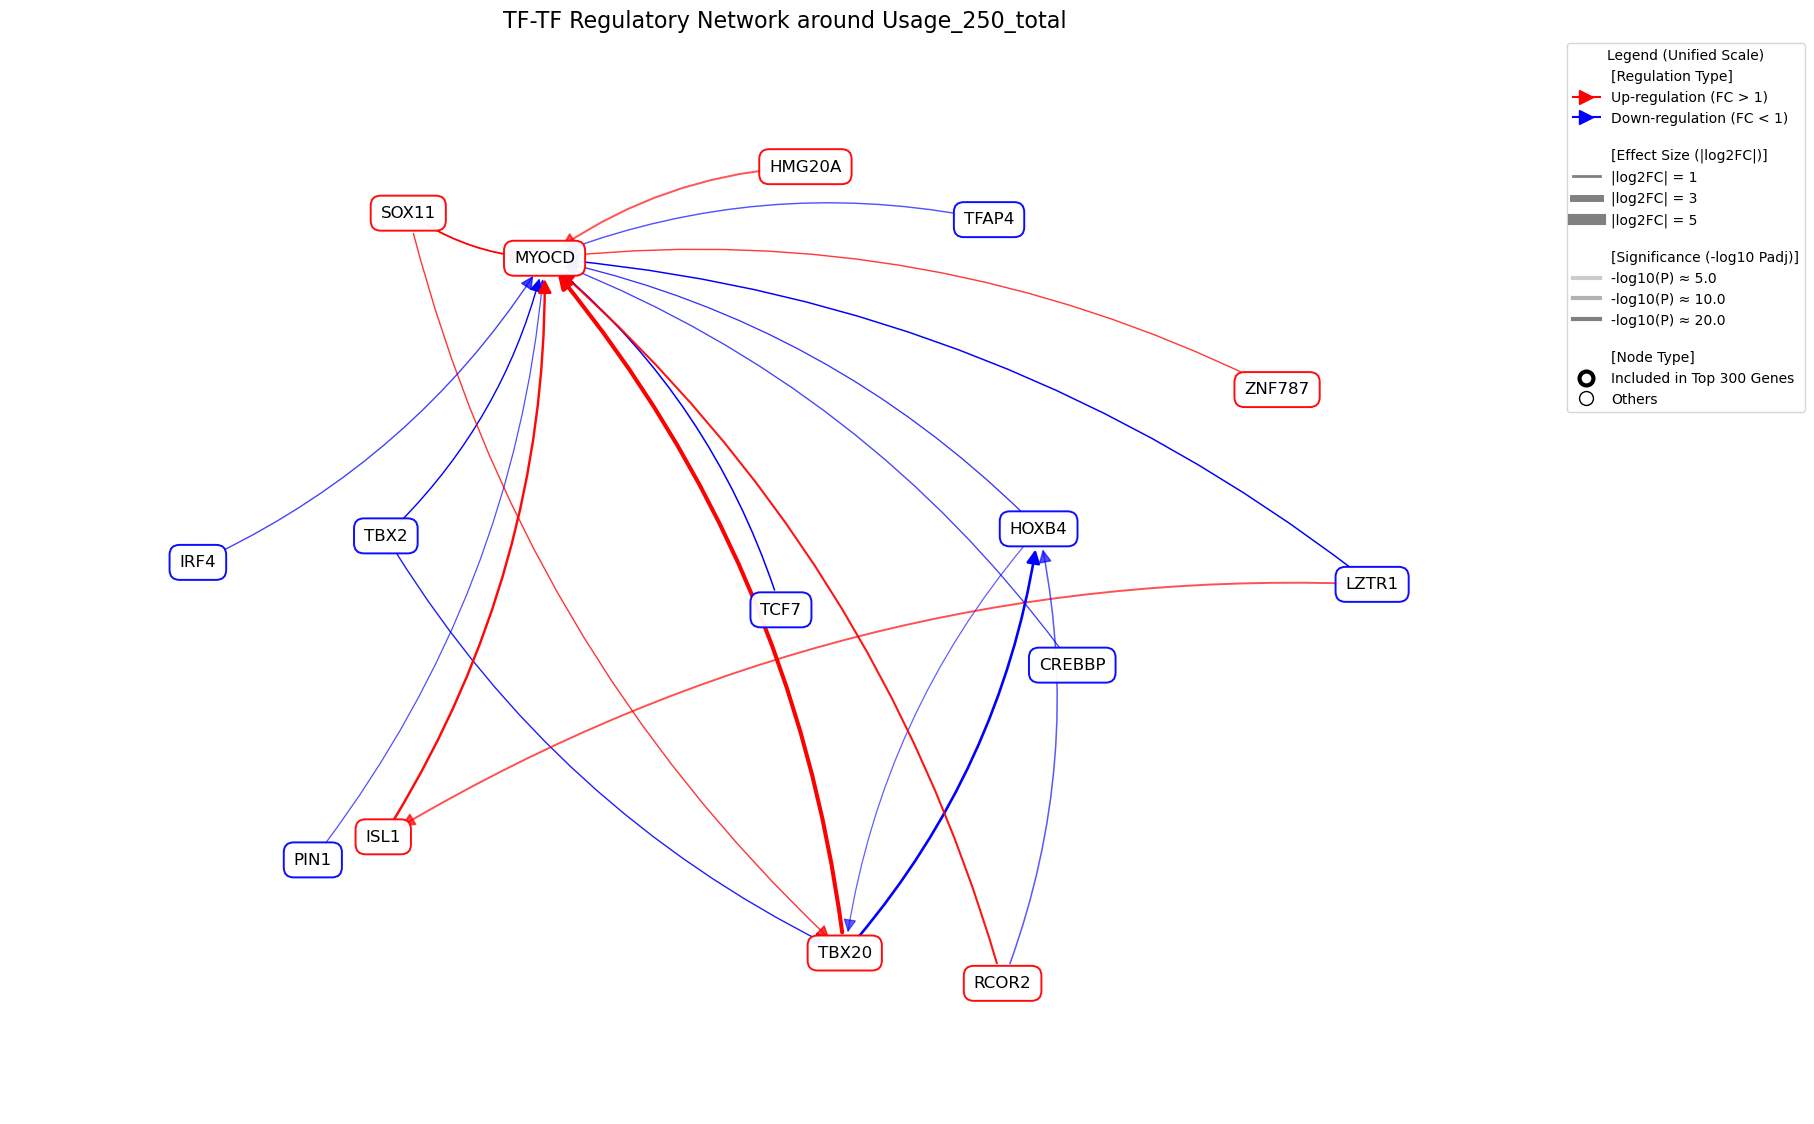

In [37]:

G = G_gp1_sub
# Layout
pos = nx.spring_layout(G, k=1.0, seed=42, iterations=50)

# Determine edge styles
edge_colors = []
edge_widths = []

for u, v, data in G.edges(data=True):
    weight = data['weight']       # log2FC
    sig = data['significance']    # -log10(p-value)

    # Width: Global scale is implicitly consistent formula-wise
    width = 0.5 + abs(weight) * 1.5
    edge_widths.append(width)

    # Color base
    if weight > 0:
        base_rgb = (0, 0, 1) # Blue
    else:
        base_rgb = (1, 0, 0) # Red

    # Opacity: Global Normalization using global_max_nlp
    alpha = 0.2 + 0.8 * (sig / max_nlp)
    alpha = min(1.0, max(0.2, alpha))

    edge_colors.append(base_rgb + (alpha,))

# Plot
plt.figure(figsize=(20, 14)) # Widen slightly to accommodate legend
ax = plt.gca()

# Edges
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15",
    min_source_margin=15,
    min_target_margin=15,
)

# Nodes
node_fontsize = 12 
node_pad = 0.60 
node_box_alpha = 0.95
node_box_lw = 1.4

for node in G.nodes():
    x, y = pos[node]

    if G.nodes()[node]["type"] == "up":
        box_color = "blue"
    elif G.nodes()[node]["type"] == "down":
        box_color = "red"
    else:
        box_color = "black"

    ax.text(
        x, y, node,
        fontsize=node_fontsize,
        fontweight='normal',
        ha='center', va='center',
        bbox=dict(
            boxstyle=f"round,pad={node_pad}",
            fc="white", ec=box_color,
            lw=node_box_lw,
            alpha=node_box_alpha
        ),
        zorder=10
    )

plt.axis("off")
plt.margins(0.1)

# Title
plt.title(f"TF-TF Regulatory Network around {key}", fontsize=16)

# Add Legend
# Place outside the plot (e.g., top right) using bbox_to_anchor
lgd = ax.legend(handles=legend_handles, loc='upper left', 
                bbox_to_anchor=(1.0, 1.0), fontsize=10, 
                title="Legend (Unified Scale)", frameon=True)
plt.savefig("../Plot/GRN_MYOCD_centric.pdf")

#### Show in heatmap

In [38]:
G_gp1_sub.nodes()

NodeView(('HMG20A', 'HOXB4', 'PIN1', 'TBX2', 'ZNF787', 'SOX11', 'LZTR1', 'TBX20', 'MYOCD', 'TCF7', 'CREBBP', 'ISL1', 'TFAP4', 'IRF4', 'RCOR2'))

In [39]:
G_gp1_sub.nodes()["TCF7"]

{'type': 'up'}

In [40]:
res_list = []
for u,v,data in G_gp1_sub.edges(data=True):
    if v != "MYOCD":
        continue
    gp1_reg = gp_regulation_df[(gp_regulation_df["Gene"].apply(lambda x:x.split("-")[0])==u) & \
                               (gp_regulation_df["Score Column"]=="Usage_1")]["Log2 Fold Change"].values
    if len(gp1_reg)>1:
        gp1_reg = gp1_reg[np.argmax(np.abs(gp1_reg))]
    else:
        gp1_reg = gp1_reg[0]
    res_list.append([u,v,data["weight"],gp1_reg])

In [41]:
# MYOCD_fc = global_df[(global_df["Pert_name"]=="MYOCD") & \
#                      (global_df["gene_names"]=="MYOCD")]["fc"].values[0]
# MYOCD_fc = np.log2(MYOCD_fc)

# gp1_reg_MYOCD = gp_regulation_df[(gp_regulation_df["Gene"].apply(lambda x:x.split("-")[0])=="MYOCD") & \
#                                (gp_regulation_df["Score Column"]=="Usage_1")]["Log2 Fold Change"].values[0]

# res_list.append(["MYOCD","MYOCD",MYOCD_fc,gp1_reg_MYOCD])

In [42]:
MYOCD_reg_df = pd.DataFrame(res_list,columns=["Upstream","Downstream","MYOCD_log2_fc","GP1_log2_fc"])
MYOCD_reg_df = MYOCD_reg_df.sort_values("MYOCD_log2_fc")

In [43]:
MYOCD_reg_df

,Upstream,Downstream,MYOCD_log2_fc,GP1_log2_fc
7,TBX20,MYOCD,-1.609371,-1.580249
10,ISL1,MYOCD,-0.833890,-0.886699
13,RCOR2,MYOCD,-0.654565,-0.879612
0,HMG20A,MYOCD,-0.637301,-0.550153
5,SOX11,MYOCD,-0.535905,-0.759025
4,ZNF787,MYOCD,-0.353855,-0.499598
2,PIN1,MYOCD,0.264724,0.395825
1,HOXB4,MYOCD,0.292872,0.647656
9,CREBBP,MYOCD,0.308843,0.353315
12,IRF4,MYOCD,0.332788,0.329723


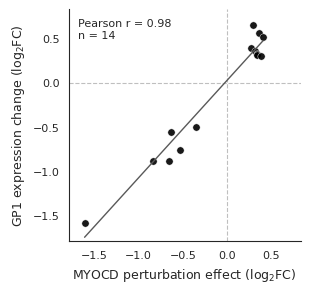

In [57]:
# Select columns and remove missing / infinite values
plot_df = (
    MYOCD_reg_df[["MYOCD_log2_fc", "GP1_log2_fc"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

# Set publication-style theme
sns.set_theme(
    context="paper",
    style="white",
    rc={
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.8,
    },
)

fig, ax = plt.subplots(figsize=(3.1, 3.0), dpi=100)

# Draw zero reference lines
ax.axhline(0, color="0.75", linewidth=0.8, linestyle="--", zorder=0)
ax.axvline(0, color="0.75", linewidth=0.8, linestyle="--", zorder=0)

# Main scatter plot
sns.scatterplot(
    data=plot_df,
    x="MYOCD_log2_fc",
    y="GP1_log2_fc",
    s=28,
    color="black",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.9,
    ax=ax,
)

# Optional: add a light regression trend line
sns.regplot(
    data=plot_df,
    x="MYOCD_log2_fc",
    y="GP1_log2_fc",
    scatter=False,
    ci=None,
    color="0.35",
    line_kws={"linewidth": 1.0},
    ax=ax,
)

# Axis labels
ax.set_xlabel("MYOCD perturbation effect (log$_2$FC)")
ax.set_ylabel("GP1 expression change (log$_2$FC)")

# Add correlation and sample size
r = plot_df["MYOCD_log2_fc"].corr(plot_df["GP1_log2_fc"], method="pearson")
ax.text(
    0.04,
    0.96,
    f"Pearson r = {r:.2f}\nn = {len(plot_df)}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8,
)

# Make axes clean
sns.despine(ax=ax)
ax.tick_params(axis="both", length=3, width=0.8)

# Use equal visual scaling because both axes are log2 fold change
x_min, x_max = plot_df["MYOCD_log2_fc"].min(), plot_df["MYOCD_log2_fc"].max()
y_min, y_max = plot_df["GP1_log2_fc"].min(), plot_df["GP1_log2_fc"].max()
lim_min = min(x_min, y_min)
lim_max = max(x_max, y_max)
pad = 0.08 * (lim_max - lim_min)

ax.set_xlim(lim_min - pad, lim_max + pad)
ax.set_ylim(lim_min - pad, lim_max + pad)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()

# Save as vector and high-resolution raster formats
fig.savefig("../Plot/MYOCD_GP1_scatterplot.pdf", bbox_inches="tight")

plt.show()

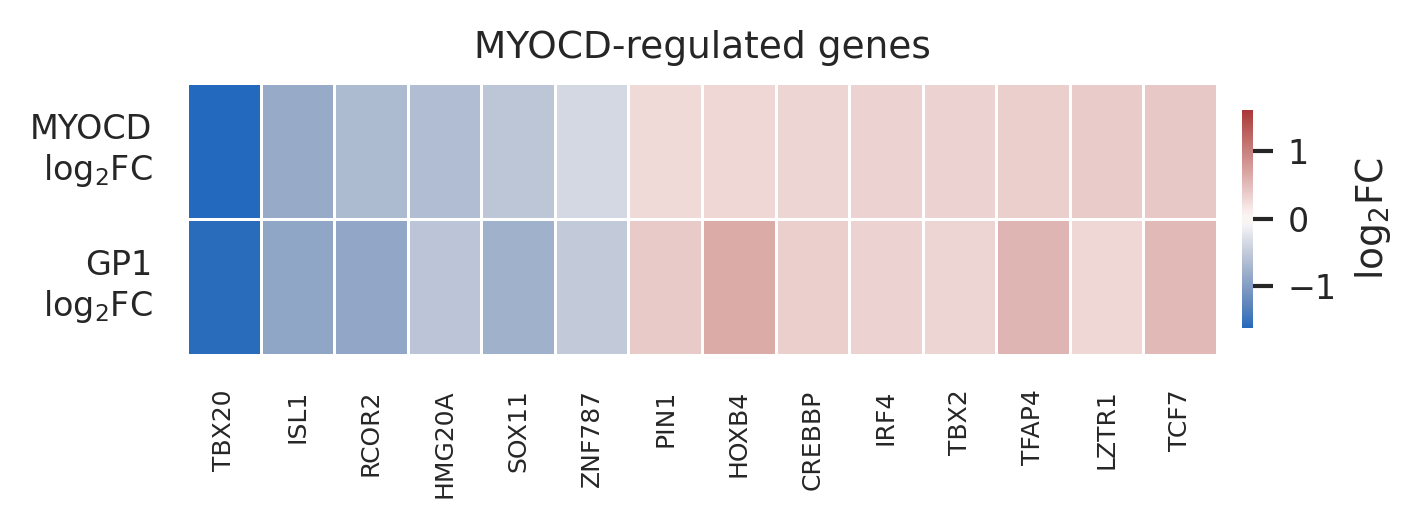

In [59]:
from matplotlib.colors import TwoSlopeNorm

# Select columns and clean data
heatmap_cols = ["MYOCD_log2_fc", "GP1_log2_fc"]

plot_df = (
    MYOCD_reg_df[heatmap_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

# Use the Upstream column as heatmap column labels after transpose
plot_df.index = MYOCD_reg_df.loc[plot_df.index, "Upstream"].astype(str)

# Make duplicated Upstream labels unique
if plot_df.index.duplicated().any():
    counts = {}
    new_index = []

    for label in plot_df.index:
        if label in counts:
            counts[label] += 1
            new_index.append(f"{label}_{counts[label]}")
        else:
            counts[label] = 0
            new_index.append(label)

    plot_df.index = new_index

# Rename rows for display after transpose
plot_df = plot_df.rename(
    columns={
        "MYOCD_log2_fc": "MYOCD\nlog$_2$FC",
        "GP1_log2_fc": "GP1\nlog$_2$FC",
    }
)

# Transpose to show Upstream labels as columns
plot_df_rot = plot_df.T

# Set publication-style theme
sns.set_theme(
    context="paper",
    style="white",
    rc={
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 6,
        "ytick.labelsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    },
)

# Use a symmetric color scale centered at zero
max_abs = np.nanmax(np.abs(plot_df_rot.values))
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

# Adjust figure size based on the number of Upstream labels
n_cols = plot_df_rot.shape[1]
fig_width = max(3.0, min(14.0, 0.35 * n_cols))

fig, ax = plt.subplots(figsize=(fig_width, 1.8), dpi=300)

sns.heatmap(
    plot_df_rot,
    cmap="vlag",
    norm=norm,
    linewidths=0.25,
    linecolor="white",
    cbar=True,
    cbar_kws={
        "label": "log$_2$FC",
        "shrink": 0.8,
        "pad": 0.02,
    },
    ax=ax,
)

# Format labels
ax.set_title("MYOCD-regulated genes", pad=6)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Show Upstream labels on the x-axis
if n_cols <= 50:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
else:
    ax.set_xticklabels([])

plt.tight_layout()

fig.savefig("../Plot/MYOCD_GP1_heatmap_Upstream_labels.pdf", bbox_inches="tight")

plt.show()

### Top5 Gene regulation in each program

In [46]:
def generate_graph_target(TF_regulation_df, tf_name_list, target_genes):
    # 2) Create a directed graph
    G = nx.DiGraph()

    # Add TF nodes to the graph
    G.add_nodes_from(tf_name_list,node_type="tf")
    G.add_nodes_from(target_genes, node_type="target")

    # 3) Add edges
    # Edge direction: regulating_tf -> tf_name
    for row in TF_regulation_df.itertuples():
        # Remove self-loops
        if row.gene_names == row.Pert_name:
            continue

        # Add directed edges with attributes
        # We store log2FC for weight/width and -log10(p-value) for opacity
        log_fc = np.log2(row.fc)
        
        # Calculate negative log p-value (add small epsilon to avoid log(0))
        # Using pval_empirical based on your data structure
        nlog_p = -row.Significance_score
        
        G.add_edge(row.Pert_name, row.gene_names,
                   weight=log_fc, significance=nlog_p)
    return G

In [47]:
graph_gp_top_dict = {}

print("Generating graphs...")
for target_gene in tqdm(gp_name_list):
    # Filter data (Same logic as your original code)
    gp_regulation_df_sig_target = \
        gp_regulation_df_sig[gp_regulation_df_sig["Score Column"]==target_gene].sort_values("Corrected p-value (BH)")

    gp_regulation_df_sig_target_down = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']<0]
    gp_regulation_df_sig_target_up = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']>0]

    target_down_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_down["Gene"].values]
    target_up_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_up["Gene"].values]
    
    gp_id_str = target_gene.split("_")[1]
    top300_list = top300_gene_df[gp_id_str].values
    
    top5_list = top300_list[:5]

    DEG_tf_regulation_down = global_df[(global_df["Pert_name"].apply(lambda x: x in target_down_tf_name)) & \
                                       (global_df["gene_names"].apply(lambda x: x in top5_list))]
    DEG_tf_regulation_up   = global_df[(global_df["Pert_name"].apply(lambda x: x in target_up_tf_name)) & \
                                       (global_df["gene_names"].apply(lambda x: x in top5_list))]
    G_up = generate_graph_target(DEG_tf_regulation_up,target_up_tf_name,top5_list)
    G_down = generate_graph_target(DEG_tf_regulation_down,target_down_tf_name,top5_list)
    
    graph_gp_top_dict[f"{target_gene}_up"] = G_up
    graph_gp_top_dict[f"{target_gene}_down"] = G_down

Generating graphs...


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 1/250 [00:00<00:46,  5.33it/s]

  1%|          | 2/250 [00:00<00:45,  5.44it/s]

  1%|          | 3/250 [00:00<00:45,  5.44it/s]

...

 99%|█████████▉| 247/250 [00:44<00:00,  5.60it/s]

 99%|█████████▉| 248/250 [00:44<00:00,  5.61it/s]

100%|█████████▉| 249/250 [00:44<00:00,  5.61it/s]

100%|██████████| 250/250 [00:44<00:00,  5.62it/s]

100%|██████████| 250/250 [00:44<00:00,  5.60it/s]

In [48]:
output_filename = "../Plot/GRN_plot_target.pdf"
max_nlp = 20
with PdfPages(output_filename) as pdf:
    # The legend objects are fixed, so create them once,
    # but ax.legend() must be called inside the loop to place them on each page
    legend_handles = create_custom_legend(max_nlp)
    
    for key, G in tqdm(graph_gp_top_dict.items()):
        if G.number_of_nodes() == 0:
            continue
            
        gp_id_str = key.split("_")[1] 
    
        tf_nodes = [n for n, attr in G.nodes(data=True) if attr.get("node_type") == 'tf']
        # Layout
        pos = nx.bipartite_layout(G, nodes=tf_nodes)

        # Determine edge styles
        edge_colors = []
        edge_widths = []
        
        for u, v, data in G.edges(data=True):
            weight = data['weight']       # log2FC
            sig = data['significance']    # -log10(p-value)
            
            # Width: Global scale is implicitly consistent formula-wise
            width = 0.5 + abs(weight) * 1.5
            edge_widths.append(width)
            
            # Color base
            if weight > 0:
                base_rgb = (0, 0, 1) # Blue
            else:
                base_rgb = (1, 0, 0) # Red
            
            # Opacity: Global Normalization using global_max_nlp
            alpha = 0.2 + 0.8 * (sig / max_nlp)
            alpha = min(1.0, max(0.2, alpha))
            
            edge_colors.append(base_rgb + (alpha,))

        # Plot
        plt.figure(figsize=(20, 14)) # Widen slightly to accommodate legend
        ax = plt.gca()

        # Edges
        nx.draw_networkx_edges(
            G,
            pos,
            edge_color=edge_colors,
            width=edge_widths,
            arrows=True,
            arrowsize=20,
            connectionstyle="arc3,rad=0.15",
            min_source_margin=15,
            min_target_margin=15,
        )

        # Nodes
        for node in G.nodes():
            x, y = pos[node]
            box_lw = 1.0
            font_weight = 'normal'

            ax.text(
                x, y, node,
                fontsize=9,
                fontweight=font_weight,
                horizontalalignment='center',
                verticalalignment='center',
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    fc="white",
                    ec="black",
                    lw=box_lw,
                    alpha=0.9
                ),
                zorder=10
            )

        plt.axis("off")
        plt.margins(0.1)
        
        # Title
        plt.title(f"TF-TF Regulatory Network around {key}", fontsize=16)

        # Add Legend
        # Place outside the plot (e.g., top right) using bbox_to_anchor
        lgd = ax.legend(handles=legend_handles, loc='upper left', 
                        bbox_to_anchor=(1.0, 1.0), fontsize=10, 
                        title="Legend (Unified Scale)", frameon=True)
        
        # Save PDF (use bbox_inches='tight' to prevent legend from being cut off)
        pdf.savefig(bbox_inches='tight', bbox_extra_artists=(lgd,))
        plt.close()

print(f"PDF saved to {output_filename}")

  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_2912264/3477213515.py:47: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


  0%|          | 1/500 [00:00<03:23,  2.45it/s]

  0%|          | 2/500 [00:00<02:23,  3.47it/s]

  1%|          | 3/500 [00:00<01:41,  4.92it/s]

...

 99%|█████████▉| 495/500 [00:48<00:00, 11.71it/s]

 99%|█████████▉| 497/500 [00:48<00:00, 11.80it/s]

100%|█████████▉| 499/500 [00:48<00:00, 11.87it/s]

100%|██████████| 500/500 [00:48<00:00, 10.29it/s]

PDF saved to ../Plot/GRN_plot_target.pdf


### GO enrichment for all gene program

In [49]:
def enrichr_dotplot(
    df: pd.DataFrame,
    top_n: int = 10,
    term_col: str = "Term",
    p_col: str = "Adjusted P-value",
    odds_col: str = "Odds Ratio",
    overlap_col: str = "Overlap",
    gene_set_filter: str | None = None,
    gene_set_col: str = "Gene_set",
    figsize=(16, 4),
    size_range=(60, 420),
    dedup_term: bool = True,
    genes_legend_values=None,
    tick_labelsize_y: int = 6,
    tick_labelsize_x: int = 8,
    title_fontsize: int = 10,
    xlabel_fontsize: int = 10,
    # Layout controls: fixed widths so every figure matches
    left_pad: float = 0.02,
    right_pad: float = 0.02,
    top_pad: float = 0.88,
    bottom_pad: float = 0.18,
    # GridSpec width ratios: [main plot, colorbar, legend]
    width_ratios=(1.0, 0.035, 0.22),
):
    d = df.copy()

    # Optional filter
    if gene_set_filter is not None and gene_set_col in d.columns:
        d = d[d[gene_set_col] == gene_set_filter].copy()

    # Pick p column
    if p_col not in d.columns:
        if "P-value" in d.columns:
            p_col = "P-value"
        else:
            raise ValueError(f"p_col='{p_col}' not found and no 'P-value' column either.")

    # Genes from Overlap "15/26" -> 15
    if overlap_col not in d.columns:
        raise ValueError(f"'{overlap_col}' column not found.")
    ov = d[overlap_col].astype(str).str.split("/", expand=True)
    d["Genes"] = pd.to_numeric(ov[0], errors="coerce")

    # Numerics
    d[term_col] = d[term_col].astype(str)
    d[p_col] = pd.to_numeric(d[p_col], errors="coerce")
    d[odds_col] = pd.to_numeric(d[odds_col], errors="coerce")
    d = d.dropna(subset=[term_col, p_col, odds_col, "Genes"]).copy()

    # -log10(p)
    d["neglog10_p"] = -np.log10(np.clip(d[p_col].values, 1e-300, 1.0))

    # Deduplicate by best (smallest) p if needed
    if dedup_term:
        d = d.sort_values(p_col, ascending=True).drop_duplicates(subset=[term_col], keep="first")

    # Select and order by p (smallest first)
    d = d.sort_values(p_col, ascending=True).head(top_n).copy()

    # Preserve order for y-axis (smallest p on top)
    term_order = pd.unique(d[term_col]).tolist()
    d[term_col] = pd.Categorical(d[term_col], categories=term_order, ordered=True)

    # Theme
    sns.set_theme(style="whitegrid")

    # --- Create fixed layout: main + colorbar axis + legend axis ---
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 3, width_ratios=width_ratios, wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])  # colorbar axis
    lax = fig.add_subplot(gs[0, 2])  # legend axis (dedicated space)
    lax.axis("off")

    # Map Genes -> marker sizes
    gmin, gmax = d["Genes"].min(), d["Genes"].max()
    smin, smax = size_range
    if gmax == gmin:
        sizes = np.full(len(d), (smin + smax) / 2.0)
    else:
        sizes = smin + (d["Genes"] - gmin) * (smax - smin) / (gmax - gmin)

    # Scatter
    sc = ax.scatter(
        d["neglog10_p"],
        d[term_col],
        s=sizes,
        c=d[odds_col],
        cmap="Reds",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.9,
    )

    # Axes styling
    ax.set_xlabel(f"-log10({p_col})", fontsize=xlabel_fontsize)
    ax.set_ylabel("")
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=tick_labelsize_y)
    ax.tick_params(axis="x", labelsize=tick_labelsize_x)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Colorbar (Odds Ratio) - fixed axis so it never overlaps or shifts
    cb = fig.colorbar(sc, cax=cax)
    cb.set_label("Odds Ratio", fontsize=9)
    cb.ax.tick_params(labelsize=8)

    # Genes legend values
    if genes_legend_values is None:
        genes_legend_values = np.unique(np.round(np.linspace(gmin, gmax, 5)).astype(int)).tolist()

    # Build size legend handles (in legend axis)
    handles, labels = [], []
    for gv in genes_legend_values:
        if gmax == gmin:
            sv = (smin + smax) / 2.0
        else:
            sv = smin + (gv - gmin) * (smax - smin) / (gmax - gmin)
        h = ax.scatter([], [], s=sv, facecolors="gray", edgecolors="black", linewidths=0.4, alpha=0.9)
        handles.append(h)
        labels.append(str(gv))

    leg = lax.legend(
        handles,
        labels,
        title="Genes",
        loc="center left",
        frameon=True,
        borderpad=0.6,
        labelspacing=0.8,
        handletextpad=0.8,
        scatterpoints=1,
    )
    leg.get_title().set_fontsize(9)
    for txt in leg.get_texts():
        txt.set_fontsize(8)

    # Manual margins (no tight_layout) -> consistent across figures
    fig.subplots_adjust(left=left_pad, right=1 - right_pad, top=top_pad, bottom=bottom_pad)

    return fig, ax

def wrap_yticklabels(ax, width=45, max_lines=3):
    # English comment: Wrap y tick labels with max lines; truncate with ellipsis
    ticks = ax.get_yticklabels()
    new_labels = []
    for t in ticks:
        wrapped = textwrap.wrap(t.get_text(), width=width)
        if len(wrapped) > max_lines:
            wrapped = wrapped[:max_lines]
            wrapped[-1] += "..."
        new_labels.append("\n".join(wrapped))
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(new_labels)

In [50]:
source_list = gp_go_df["Source"].unique()

output_filename = "../Plot/GP_GeneOntology_enrich.pdf"
with PdfPages(output_filename) as pdf:
    for source_name in tqdm(source_list):
        gp_go_df_target = gp_go_df[gp_go_df["Source"] == source_name]

        fig, ax = enrichr_dotplot(
            gp_go_df_target,
            top_n=10,
            figsize=(16, 4),
            width_ratios=(0.3, 0.015, 0.22),  # main / cbar / legend
            left_pad=0.02, right_pad=0.02, top_pad=0.88, bottom_pad=0.20,
            tick_labelsize_y=6,
        )

        # Optional: only if very long terms break layout readability
        wrap_yticklabels(ax, width=50, max_lines=3)

        ax.set_title(f"Gene Program {source_name}", fontsize=10)
        pdf.savefig(fig, bbox_inches="tight", pad_inches=0.10)
        plt.close()

print(f"PDF saved to {output_filename}")


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 1/250 [00:00<00:57,  4.30it/s]

  1%|          | 2/250 [00:00<00:55,  4.48it/s]

  1%|          | 3/250 [00:00<00:55,  4.46it/s]

  2%|▏         | 4/250 [00:00<00:54,  4.48it/s]

...

 99%|█████████▉| 248/250 [00:59<00:00,  4.72it/s]

100%|█████████▉| 249/250 [00:59<00:00,  4.63it/s]

100%|██████████| 250/250 [01:00<00:00,  4.54it/s]

100%|██████████| 250/250 [01:00<00:00,  4.15it/s]

PDF saved to ../Plot/GP_GeneOntology_enrich.pdf


### Analyze Centrality of TFs in each GPs

In [51]:
regulation_df_dict["Usage_1_total"].head(3)

,target_node,target_node_type,upstream_node,upstream_node_type,fc,is_valid
25,MYOCD,down,TCF7,up,0.403767,True
24,MYOCD,down,TBX2,up,0.338754,True
26,MYOCD,down,LZTR1,up,0.377806,True


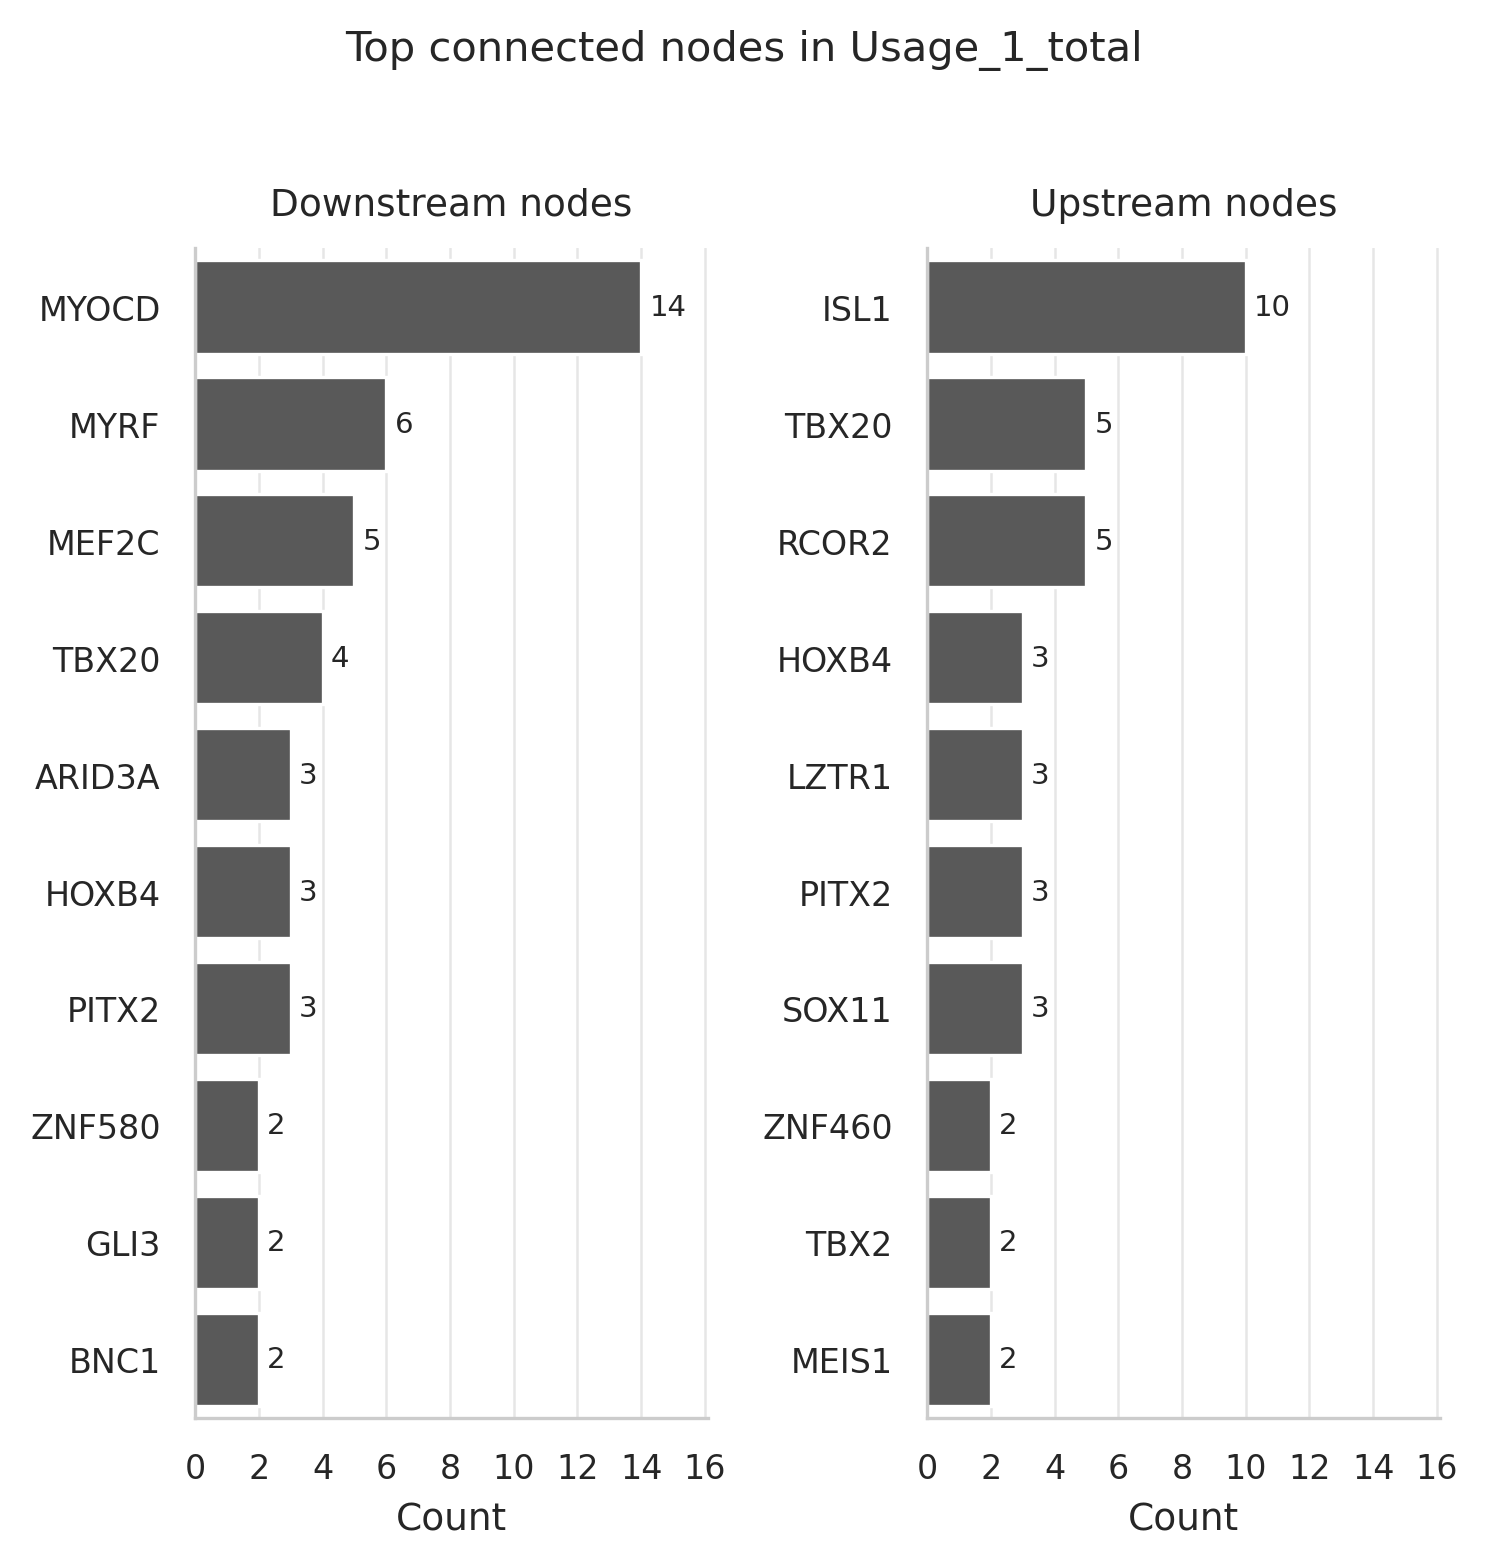

In [54]:
from matplotlib.ticker import MaxNLocator

# Number of nodes to display
top_n = 10

# Aggregate downstream counts
count_df_downstream = (
    regulation_df_dict["Usage_1_total"]
    .groupby("target_node")["target_node_type"]
    .count()
    .rename("count")
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)

count_df_downstream.columns = ["node", "count"]

# Aggregate upstream counts
count_df_upstream = (
    regulation_df_dict["Usage_1_total"]
    .groupby("upstream_node")["target_node_type"]
    .count()
    .rename("count")
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)

count_df_upstream.columns = ["node", "count"]

# Paper-friendly styling
sns.set_theme(
    style="whitegrid",
    context="paper",
    rc={
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.8,
    },
)

# Create side-by-side panels
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(5, 5),
    dpi=300,
    sharex=True,
)

# Left panel: downstream nodes
sns.barplot(
    data=count_df_downstream,
    x="count",
    y="node",
    ax=axes[0],
    color="0.35",
)

axes[0].set_title("Downstream nodes", pad=8)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Right panel: upstream nodes
sns.barplot(
    data=count_df_upstream,
    x="count",
    y="node",
    ax=axes[1],
    color="0.35",
)

axes[1].set_title("Upstream nodes", pad=8)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Add count labels to bars
for ax in axes:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%d",
            padding=2,
            fontsize=7,
        )

# Use the same x-axis limit for easier comparison
max_count = max(
    count_df_downstream["count"].max(),
    count_df_upstream["count"].max(),
)

for ax in axes:
    ax.set_xlim(0, max_count * 1.15)
    ax.grid(axis="x", color="0.9", linewidth=0.6)
    ax.grid(axis="y", visible=False)

# Clean up spines
sns.despine(fig=fig, left=False, bottom=False)

# Overall title
fig.suptitle("Top connected nodes in Usage_1_total", y=1.03, fontsize=10)

plt.tight_layout()

fig.savefig("../Plot/GP1_downstream_upstream_side_by_side.pdf", bbox_inches="tight")

plt.show()

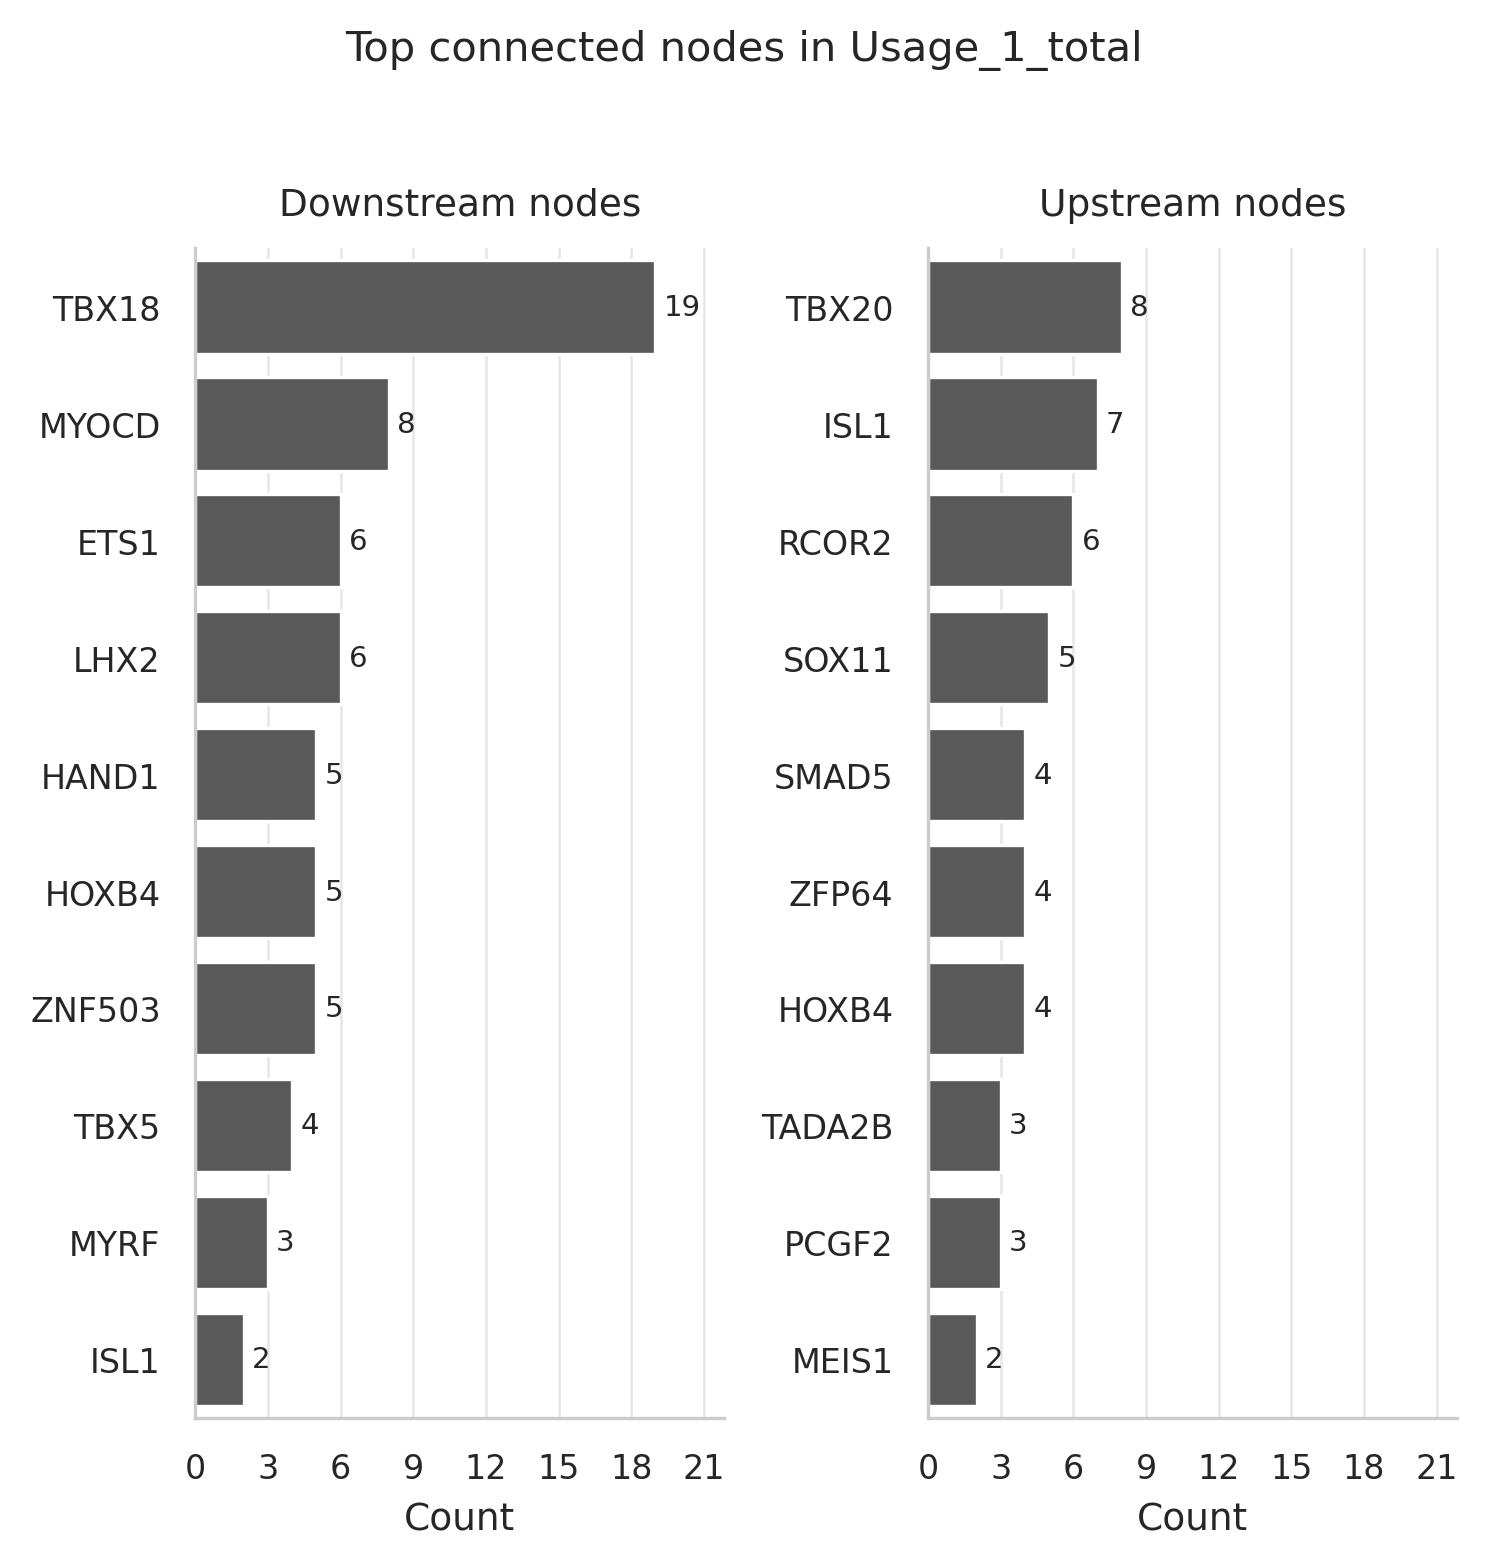

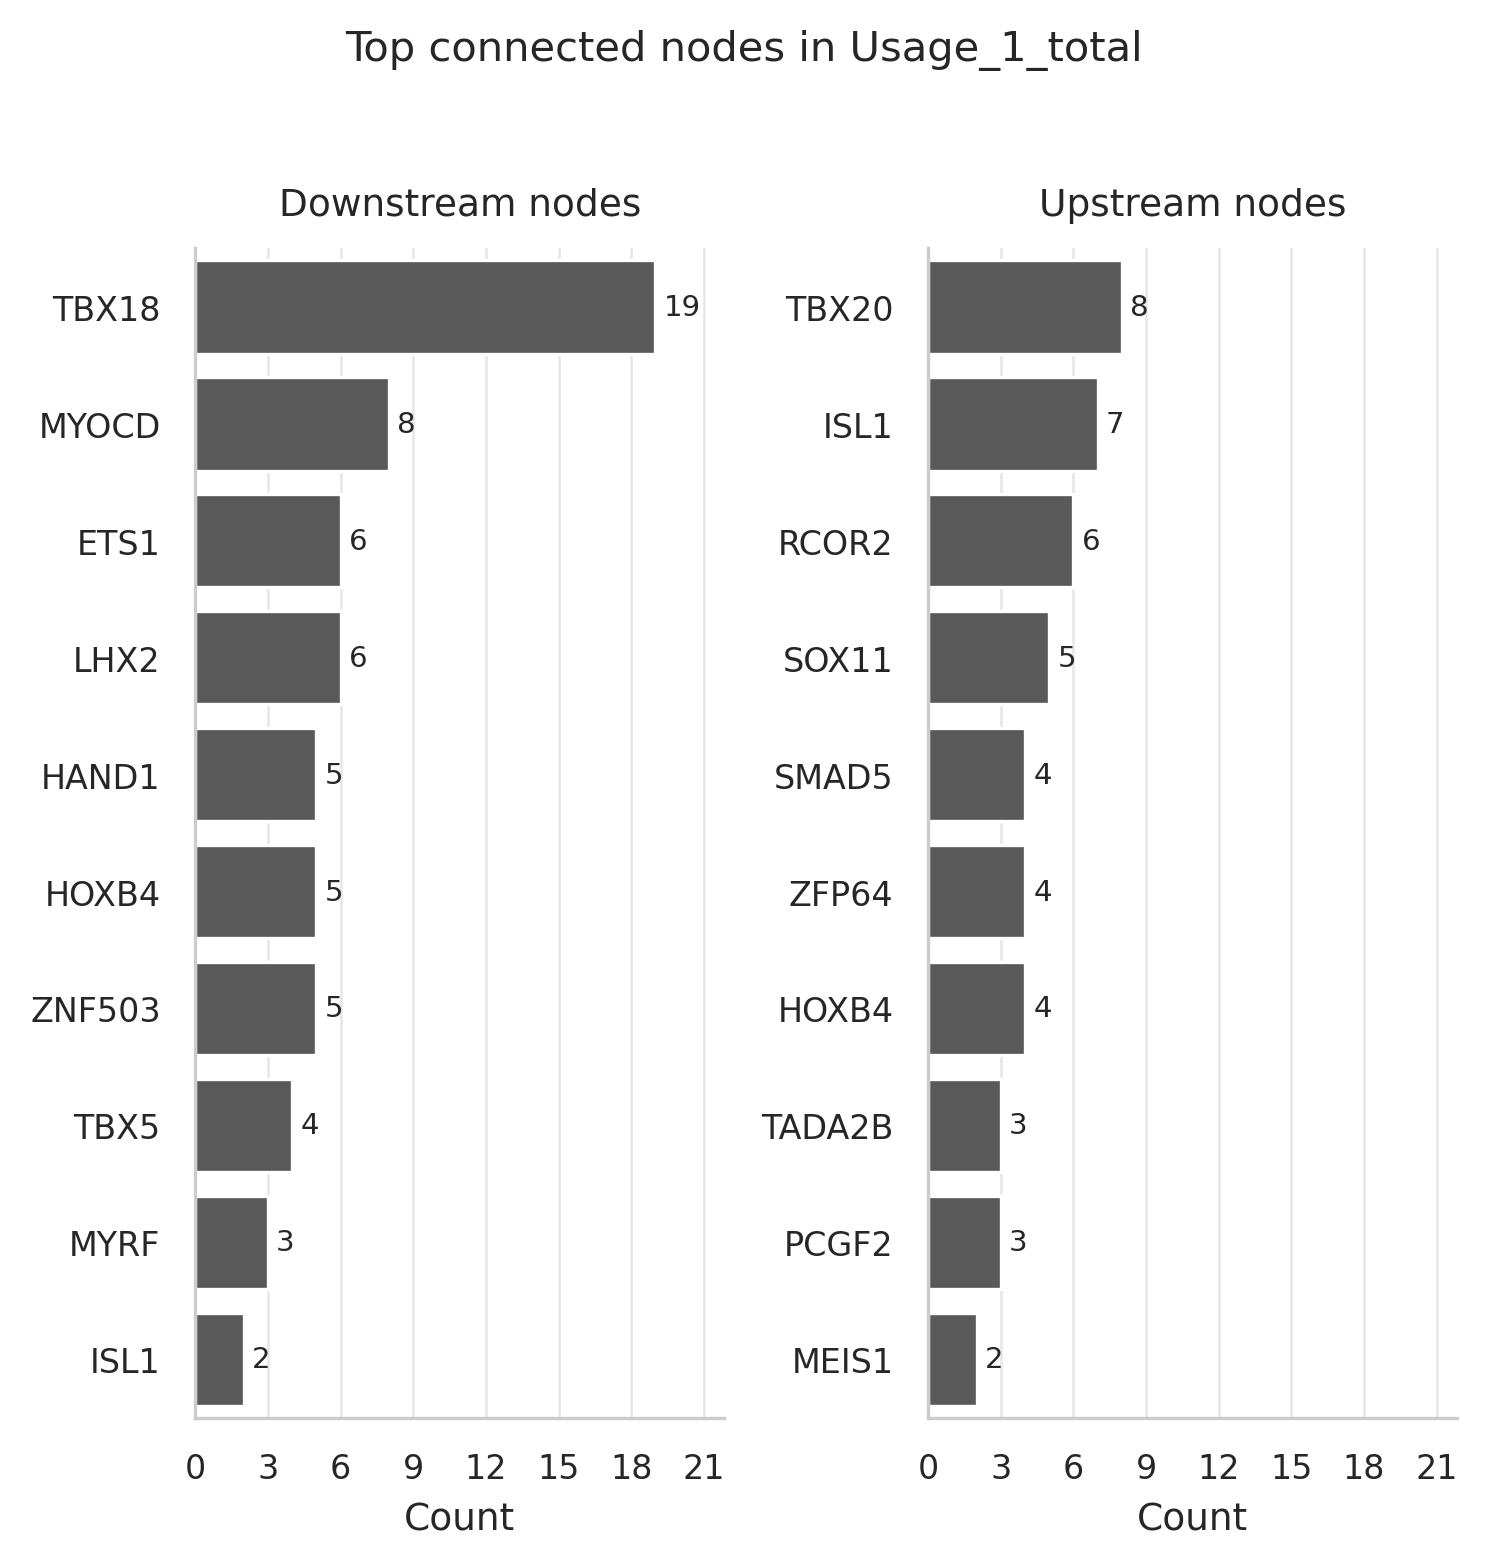

In [ ]:
from matplotlib.ticker import MaxNLocator

# Number of nodes to display
top_n = 10

# Aggregate downstream counts
count_df_downstream = (
    regulation_df_dict["Usage_3_total"]
    .groupby("target_node")["target_node_type"]
    .count()
    .rename("count")
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)

count_df_downstream.columns = ["node", "count"]

# Aggregate upstream counts
count_df_upstream = (
    regulation_df_dict["Usage_3_total"]
    .groupby("upstream_node")["target_node_type"]
    .count()
    .rename("count")
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)

count_df_upstream.columns = ["node", "count"]

# Paper-friendly styling
sns.set_theme(
    style="whitegrid",
    context="paper",
    rc={
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.8,
    },
)

# Create side-by-side panels
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(5, 5),
    dpi=300,
    sharex=True,
)

# Left panel: downstream nodes
sns.barplot(
    data=count_df_downstream,
    x="count",
    y="node",
    ax=axes[0],
    color="0.35",
)

axes[0].set_title("Downstream nodes", pad=8)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Right panel: upstream nodes
sns.barplot(
    data=count_df_upstream,
    x="count",
    y="node",
    ax=axes[1],
    color="0.35",
)

axes[1].set_title("Upstream nodes", pad=8)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Add count labels to bars
for ax in axes:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%d",
            padding=2,
            fontsize=7,
        )

# Use the same x-axis limit for easier comparison
max_count = max(
    count_df_downstream["count"].max(),
    count_df_upstream["count"].max(),
)

for ax in axes:
    ax.set_xlim(0, max_count * 1.15)
    ax.grid(axis="x", color="0.9", linewidth=0.6)
    ax.grid(axis="y", visible=False)

# Clean up spines
sns.despine(fig=fig, left=False, bottom=False)

# Overall title
fig.suptitle("Top connected nodes in Usage_1_total", y=1.03, fontsize=10)

plt.tight_layout()

fig.savefig("../Plot/GP3_downstream_upstream_side_by_side.pdf", bbox_inches="tight")

plt.show()